# Task 1: Running the Apple Data Download Script

In [6]:
%run /content/apple_data_download.py

/content/apple_data_download.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download('AAPL', start='2020-01-01', end='2023-12-31', group_by='column')
[*********************100%***********************]  1 of 1 completed

In [3]:
import yfinance as yf
import os

# Script content to download AAPL data
script_content = """
import yfinance as yf
def download_data():
    print('Downloading AAPL data...')
    aapl = yf.download('AAPL', start='2020-01-01', end='2023-12-31', group_by='column')
    return aapl

aapl = download_data()
"""

with open('/content/apple_data_download.py', 'w') as f:
    f.write(script_content)

print('Script apple_data_download.py created successfully.')

Script apple_data_download.py created successfully.


In [4]:
%run /content/apple_data_download.py
display(aapl.head())

/content/apple_data_download.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download('AAPL', start='2020-01-01', end='2023-12-31', group_by='column')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


### Fixing variable references
Since the data is now loaded, I will fix the earlier demonstration cell that failed due to the `aapl` variable being missing.

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Re-running the preparation for the Multicollinearity demo
# Note: 'aapl' is already defined in the kernel from cell edbee109
demo_df = aapl['Close'].copy()
demo_df.columns = ['Close']
demo_df['Lag_1'] = demo_df['Close'].shift(1)
demo_df['Close_Noise'] = demo_df['Close'] * 1.001 + np.random.normal(0, 0.01, len(demo_df))
demo_df = demo_df.dropna()

X = demo_df[['Close', 'Lag_1', 'Close_Noise']]
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

display(vif_data)

,Feature,VIF
0,Close,1.791876e+08
1,Lag_1,3.008267e+03
2,Close_Noise,1.792143e+08


# Task 2: Analyzing the PDF Assignment
I will use `PyMuPDF` (fitz) to extract the text from the PDF file for analysis.

In [8]:
!pip install -q pymupdf

import fitz

pdf_path = '/content/HASTS 201-Financial_Econometrics Asignment 1 (1).pdf'
doc = fitz.open(pdf_path)

text = ""
for page in doc:
    text += page.get_text()

print("PDF Content Extracted successfully. Here is a preview:")
print(text[:1000] + "...")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 66.0 MB/s eta 0:00:00
PDF Content Extracted successfully. Here is a preview:
 
 
 
 
FINANCIAL ECONOMETRICS  
Project # 1  
See grading rubric here.  
Scenario  
Suppose you are a team of newly hired quants on the derivatives desk. As your ﬁrst 
responsibility,  you  will  be  tasked  with  modeling  volatility  for  the  traders  and  risk 
managers. This is a very important—and highly visible—role. Perform it correctly and 
your group’s expertise will show competitive derivative pricing and hedging, which is 
attached to a robust revenue stream. Perform it incorrectly and…well, let’s not do that. 
However,  there  are  many problems that affect the modeling of time series. These 
include: 
●  
●  
●  
●  
●  
●  
 
multicollinearity  
skewness  
lack of interpretation  
sensitivity to outliers  
overﬁtting  
prioritizing factors 
 
Tasks  
Your  will create a best-practices handbook that provides thoughtful guidelines for 
addr

# Challenge 1: Multicollinearity

### Definition
Multicollinearity occurs in a multiple regression model when two or more predictor variables are highly correlated with each other. This means one predictor can be linearly predicted from the others with a substantial degree of accuracy. In the context of financial econometrics, this often happens when using multiple technical indicators or macroeconomic variables that move in tandem.

### Mathematical Representation
Multicollinearity is often detected using the **Variance Inflation Factor (VIF)**. For a specific predictor $X_j$, the VIF is calculated as:

$$VIF_j = \frac{1}{1 - R_j^2}$$

Where:
- $R_j^2$ is the coefficient of determination of a regression of $X_j$ onto all the other predictors in the model.

### Implications
- It increases the variance of the coefficient estimates, making them unstable and sensitive to small changes in the model.
- It makes it difficult to determine the individual effect of each predictor on the response variable (loss of interpretability).

### The Danger of Ignoring Multicollinearity in Finance

When a derivatives desk ignores multicollinearity, the primary risk is **spurious hedging and unstable pricing**:

1.  **Unreliable Sensitivity (Greeks)**: In financial modeling, we rely on 'Greeks' (like Delta or Vega) which are partial derivatives. Multicollinearity makes coefficient estimates ($ \beta $) highly sensitive to small changes in data. A trader might see a Delta that suggests they are market-neutral when they actually have a massive hidden exposure.
2.  **Portfolio Over-concentration**: If two indicators are 95% correlated but treated as independent, a risk manager might believe they are diversified across two different factors when they are actually doubling down on a single risk.
3.  **Model Breakage during Regimes**: Correlated variables often 'de-couple' during market stress. A model built on multicollinear variables will provide nonsensical results exactly when the market crashes and stable guidance is needed most.

### Methods to Address Multicollinearity

1. **Principal Component Analysis (PCA)**: Transform correlated features into a set of linearly uncorrelated 'principal components.' By keeping only the top components, we retain most of the information while eliminating collinearity.
2. **Regularization (Ridge/Lasso Regression)**: Adds a penalty term to the loss function. **Ridge ($L_2$)** shrinks coefficients of correlated variables towards each other, while **Lasso ($L_1$)** can force redundant coefficients to zero, effectively performing feature selection.
3. **Feature Removal**: Simply drop one of the highly correlated variables if it doesn't provide unique economic value.

--- Correlation Matrix ---


,Close,Lag_1,Close_Noise
Close,1.000000,0.996981,1.000000
Lag_1,0.996981,1.000000,0.996982
Close_Noise,1.000000,0.996982,1.000000



--- Variance Inflation Factors (VIF) ---


,Feature,VIF
0,Close,2.097811e+08
1,Lag_1,3.012790e+03
2,Close_Noise,2.098476e+08


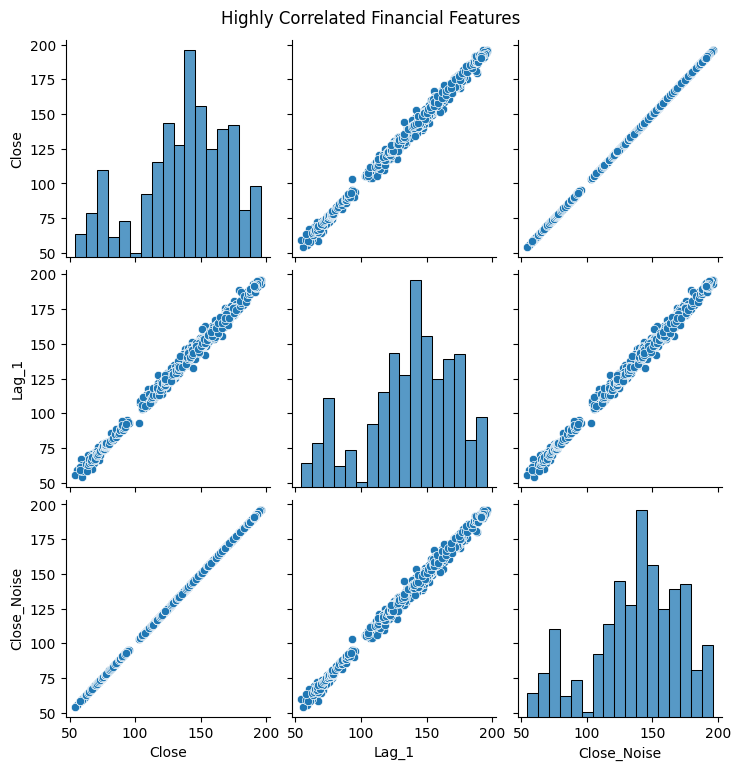

In [9]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for demonstration
# We will use the AAPL 'Close' price and create highly correlated features
demo_df = aapl['Close'].copy()
demo_df.columns = ['Close']
demo_df['Lag_1'] = demo_df['Close'].shift(1)
demo_df['Close_Noise'] = demo_df['Close'] * 1.001 + np.random.normal(0, 0.01, len(demo_df))

# Drop NaN values created by shifting
demo_df = demo_df.dropna()

# Calculate VIF for each feature
# VIF needs a constant (intercept) to be calculated correctly in some contexts, but here we focus on features
X = demo_df[['Close', 'Lag_1', 'Close_Noise']]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("--- Correlation Matrix ---")
display(X.corr())

print("\n--- Variance Inflation Factors (VIF) ---")
display(vif_data)

# Visualizing the relationship
sns.pairplot(demo_df)
plt.suptitle('Highly Correlated Financial Features', y=1.02)
plt.show()

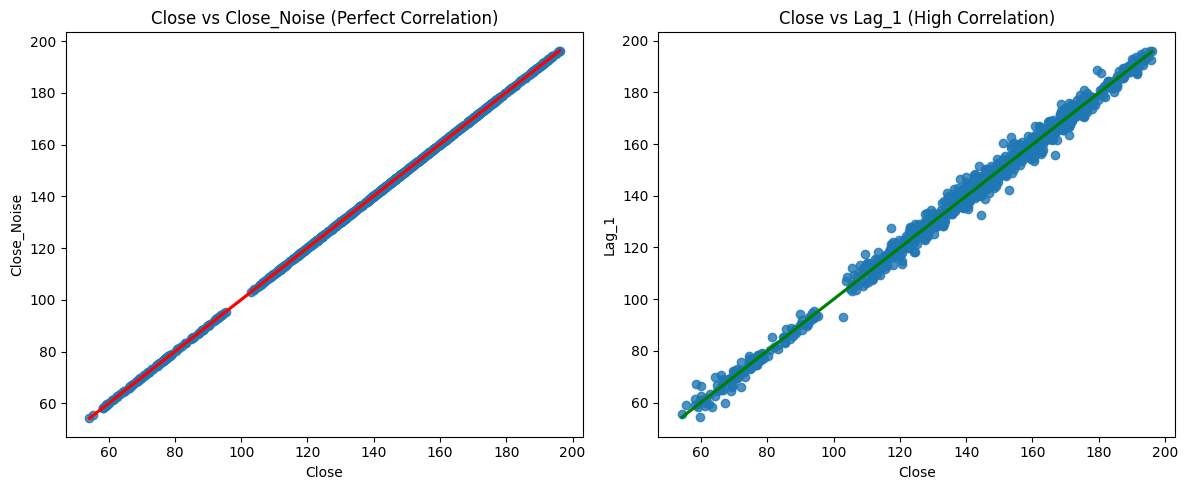

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a visualization to show the near-perfect linear relationship
plt.figure(figsize=(12, 5))

# Plot 1: Close vs Close_Noise
plt.subplot(1, 2, 1)
sns.regplot(x='Close', y='Close_Noise', data=demo_df, line_kws={'color':'red'})
plt.title('Close vs Close_Noise (Perfect Correlation)')

# Plot 2: Close vs Lag_1
plt.subplot(1, 2, 2)
sns.regplot(x='Close', y='Lag_1', data=demo_df, line_kws={'color':'green'})
plt.title('Close vs Lag_1 (High Correlation)')

plt.tight_layout()
plt.show()

### Statistical Tests for Detection

To identify multicollinearity formally, we use the following diagnostics:

1. **Variance Inflation Factor (VIF)**:
   - **Rule of Thumb**: A VIF value greater than 5 or 10 indicates high multicollinearity.
   - **Interpretation**: A VIF of 10 means the variance of the coefficient is 10 times larger than it would be if the variable were perfectly independent.

2. **Condition Number**:
   - This is calculated based on the eigenvalues of the predictor matrix ($X^TX$).
   - **Rule of Thumb**: A condition number between 10 and 30 suggests moderate multicollinearity, while a value greater than 30 suggests severe multicollinearity.

3. **Correlation Matrix Check**:
   - Examining the pairwise correlation coefficients ($r$) between independent variables. While simple, it only detects 'bivariate' collinearity and may miss complex linear relationships between three or more variables.

In [11]:
from numpy.linalg import cond

# Calculating the Condition Number for our demonstration data
condition_number = cond(X.values)

print(f"Variance Inflation Factors:\n{vif_data}")
print(f"\nCondition Number: {condition_number:.2f}")

if condition_number > 30:
    print("\nResult: Severe multicollinearity detected (Condition Number > 30)")

Variance Inflation Factors:
       Feature           VIF
0        Close  2.097811e+08
1        Lag_1  3.012790e+03
2  Close_Noise  2.098476e+08

Condition Number: 35464.45

Result: Severe multicollinearity detected (Condition Number > 30)


## Challenge 2: Skewness

### Why it matters in Finance
In financial econometrics, skewness refers to the asymmetry of the return distribution. While a normal distribution is symmetric (skewness = 0), financial returns typically exhibit **negative skewness**. This implies that the distribution has a long left tail, indicating a higher probability of extreme negative returns (market crashes) than extreme positive ones.

### The Danger of Ignoring It
If a risk manager assumes normality when the data is negatively skewed, they will significantly underestimate the **Value at Risk (VaR)** and **Expected Shortfall**. In short, the model says a crash is 'impossible,' but the data shows it is 'probable.'

### The Danger of Ignoring Skewness in Finance

When financial models assume a Normal (Gaussian) distribution but the underlying data is negatively skewed, several critical failures occur:

1.  **Underestimation of Tail Risk (VaR Failure)**: Value-at-Risk (VaR) calculations will significantly underestimate the potential for extreme losses. A '3-sigma' event that a normal model says should happen once every few years might actually happen every few months.
2.  **Option Mispricing**: The Black-Scholes model assumes log-normality. If returns are skewed, the model will fail to price 'out-of-the-money' (OTM) puts correctly, leading to the **Volatility Smile/Skew** phenomenon where the market pays a premium for crash protection that the model says is unnecessary.
3.  **Capital Adequacy Errors**: Banks and hedge funds may hold insufficient capital reserves because their risk models do not account for the frequency and magnitude of market 'gaps' or crashes.
4.  **Inefficient Portfolio Allocation**: Modern Portfolio Theory (MPT) relies on mean and variance. If an asset has a positive mean but high negative skewness, a standard optimizer will over-allocate to it, unaware of the 'hidden' crash risk.

### The Danger of Ignoring Skewness in Finance

Ignoring skewness leads to the **systematic underestimation of 'tail risk'**:

1.  **VaR Failure**: Standard Value-at-Risk (VaR) models often assume a Normal distribution. In a negatively skewed market, the actual probability of a '5-sigma' event is much higher than the model predicts. This leads to banks holding insufficient capital to survive a crash.
2.  **Option Mispricing**: The Black-Scholes model assumes log-normality. If skewness is ignored, deep 'out-of-the-money' put options will be priced too cheaply, leading to the 'volatility smile' where the market charges more for protection than the model says is necessary.
3.  **The 'Picking Up Nickels' Trap**: Strategies that ignore negative skewness (like shorting volatility) look profitable for years but eventually suffer 'blow-ups' that wipe out all previous gains in a single day.

### Definition
Skewness is a measure of the asymmetry of the probability distribution of a real-valued random variable about its mean. In financial returns, it indicates whether extreme deviations are more likely to be positive or negative.

### Mathematical Representation
The most common measure is the **Fisher-Pearson coefficient of skewness**, defined as the third standardized moment:

$$\text{Skewness} = E\left[ \left( \frac{X - \mu}{\sigma} \right)^3 \right]$$

For a sample of $n$ observations, the adjusted sample skewness is calculated as:

$$g_1 = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n} \left( \frac{x_i - \bar{x}}{s} \right)^3$$

Where:
- $\bar{x}$ is the sample mean.
- $s$ is the sample standard deviation.
- $n$ is the number of observations.

**Interpretation:**
- **Zero Skewness:** Symmetric distribution (e.g., Normal Distribution).
- **Positive Skewness:** Long right tail (more frequent extreme positive returns).
- **Negative Skewness:** Long left tail (more frequent extreme negative returns/crashes).

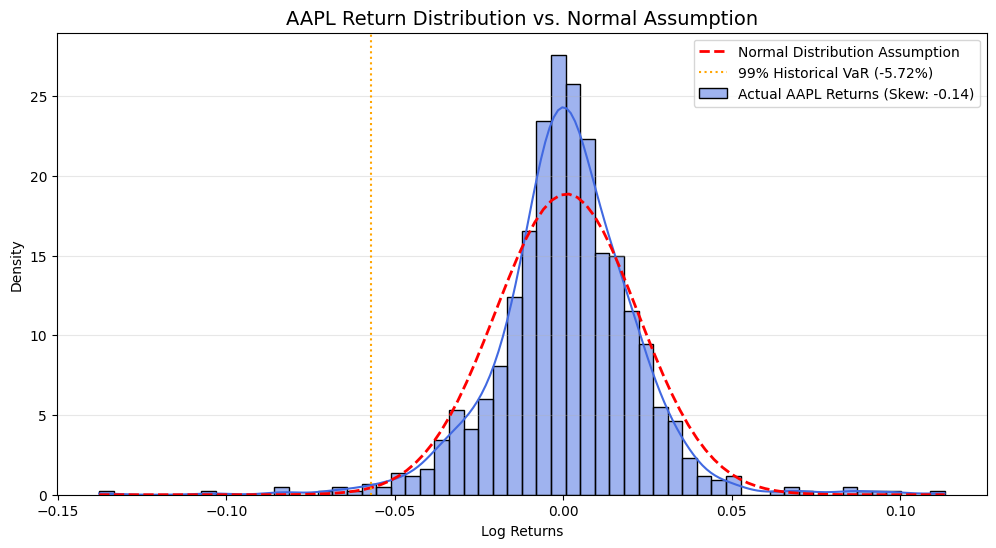

In [12]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate Log Returns
# Accessing the AAPL 'Close' price from the MultiIndex dataframe
returns = np.log(aapl['Close']['AAPL'] / aapl['Close']['AAPL'].shift(1)).dropna()

# 2. Setup the Visualization
plt.figure(figsize=(12, 6))
sns.histplot(returns, kde=True, stat="density", color='royalblue', label=f'Actual AAPL Returns (Skew: {returns.skew():.2f})')

# 3. Create a Normal Distribution for comparison
mu, std = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r--', linewidth=2, label='Normal Distribution Assumption')

# 4. Highlight the Risk (VaR)
var_99 = np.percentile(returns, 1)
plt.axvline(var_99, color='orange', linestyle=':', label=f'99% Historical VaR ({var_99:.2%})')

plt.title('AAPL Return Distribution vs. Normal Assumption', fontsize=14)
plt.xlabel('Log Returns')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Statistical Tests for Detection

To formally determine if a distribution deviates significantly from normality due to skewness, we use the following tests:

1. **Jarque-Bera Test**: This test measures whether the sample data has the skewness and kurtosis matching a normal distribution. The test statistic is always non-negative.
   - **Formula**: $JB = \frac{n}{6} \left( S^2 + \frac{1}{4}(K-3)^2 \right)$
   - **Null Hypothesis ($H_0$)**: The data is normally distributed (Skewness = 0, Kurtosis = 3).

2. **D'Agostino's K-squared Test**: This test combines skewness and kurtosis to determine if the distribution departs from normality.

3. **Kolmogorov-Smirnov Test**: A non-parametric test that compares the cumulative distribution function (CDF) of the sample data with the CDF of a normal distribution.

In [13]:
from scipy.stats import jarque_bera, normaltest

# 1. Run Jarque-Bera Test
jb_stat, jb_p_value = jarque_bera(returns)

# 2. Run D'Agostino's K-squared Test
k2_stat, k2_p_value = normaltest(returns)

print(f"--- Statistical Normality Tests for AAPL Returns ---")
print(f"Jarque-Bera Statistic: {jb_stat:.2f}, p-value: {jb_p_value:.4e}")
print(f"D'Agostino K2 Stat:   {k2_stat:.2f}, p-value: {k2_p_value:.4e}")

# Interpretation
alpha = 0.05
if jb_p_value < alpha:
    print("\nResult: Reject Null Hypothesis (Data is significantly non-normal)")
else:
    print("\nResult: Fail to reject Null Hypothesis (Data appears normal)")

--- Statistical Normality Tests for AAPL Returns ---
Jarque-Bera Statistic: 1034.49, p-value: 2.3030e-225
D'Agostino K2 Stat:   120.69, p-value: 6.1910e-27

Result: Reject Null Hypothesis (Data is significantly non-normal)


### Methods to Address Skewness

To mitigate the risk of underestimating extreme events due to skewness, quants employ several techniques:

1. **Cornish-Fisher Expansion**: This method adjusts the standard normal quantile ($z$) to account for skewness ($S$) and kurtosis ($K$), providing a more accurate VaR estimate without assuming a new distribution.
   
   $$z_{cf} = z + \frac{1}{6}(z^2 - 1)S + \frac{1}{24}(z^3 - 3z)K - \frac{1}{36}(2z^3 - 5z)S^2$$

2. **Student's t-Distribution**: Using a distribution with 'fatter tails' (higher kurtosis) often fits financial data better than the Normal distribution, as it accounts for the higher frequency of extreme moves.

3. **GARCH with Non-Normal Errors**: Modeling volatility with GARCH processes that use Skewed Student's t-distributions captures both time-varying volatility and the inherent asymmetry of returns.

4. **Non-parametric Historical Simulation**: Instead of assuming any mathematical distribution, quants use the actual empirical distribution of past returns to calculate risk metrics, which naturally incorporates historical skewness and 'black swan' events.

### Models to Fix Skewness Issues

1. **GARCH with Skewed Student's t-distribution**: Standard GARCH models assume normality. Using a skewed t-distribution allows the model to explicitly parameterize the 'fat' left tail and asymmetry observed in financial returns.
2. **Cornish-Fisher VaR**: Adjusts the standard Value-at-Risk formula using the third and fourth moments (skewness and kurtosis) to provide a more accurate risk threshold.
3. **Power Transformations**: Applying a Box-Cox or Yeo-Johnson transformation can sometimes stabilize variance and make the distribution more symmetric for linear modeling.

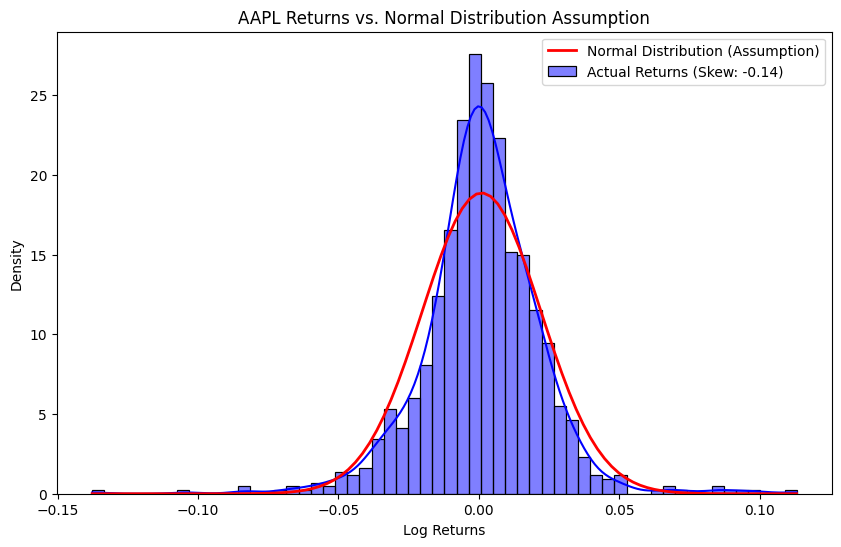

--- Risk Underestimation Analysis ---
Parametric VaR (Normal Assumption): -0.0482
Historical VaR (Actual Data):       -0.0572
Underestimation Gap:              18.65%


In [14]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate log returns from the AAPL data
# Note: aapl was defined in the first task via the %run script
returns = np.log(aapl['Close']['AAPL'] / aapl['Close']['AAPL'].shift(1)).dropna()

# Calculate Skewness
actual_skew = returns.skew()

# Visualizing the Distribution vs. Normal Distribution
plt.figure(figsize=(10, 6))
sns.histplot(returns, kde=True, stat="density", color='blue', label=f'Actual Returns (Skew: {actual_skew:.2f})')

# Overlay a Normal Distribution for comparison
mu, std = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2, label='Normal Distribution (Assumption)')

plt.title('AAPL Returns vs. Normal Distribution Assumption')
plt.xlabel('Log Returns')
plt.ylabel('Density')
plt.legend()
plt.show()

# Calculate 99% VaR under both assumptions
# Parametric VaR assumes normality
var_normal = stats.norm.ppf(0.01, mu, std)
# Historical VaR uses actual percentiles
var_empirical = np.percentile(returns, 1)

print(f"--- Risk Underestimation Analysis ---")
print(f"Parametric VaR (Normal Assumption): {var_normal:.4f}")
print(f"Historical VaR (Actual Data):       {var_empirical:.4f}")
print(f"Underestimation Gap:              {abs(var_empirical - var_normal) / abs(var_normal) * 100:.2f}%")

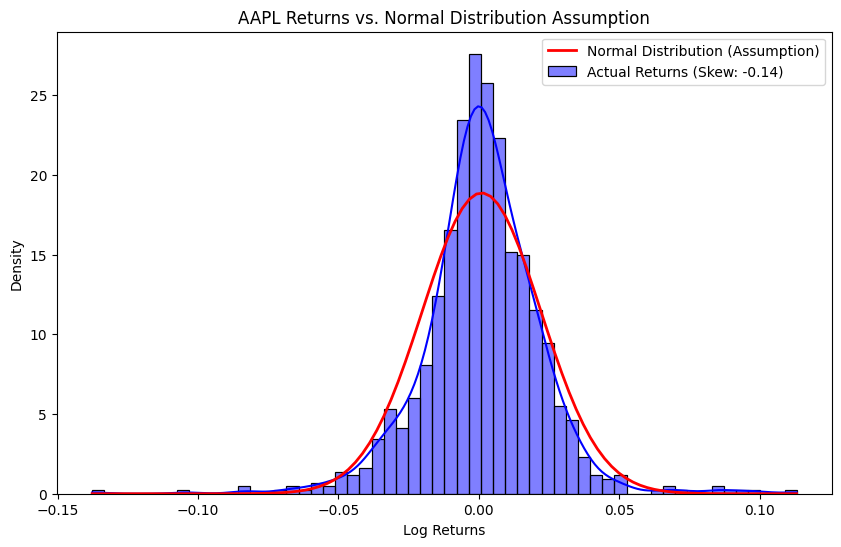

--- Risk Underestimation Analysis ---
Parametric VaR (Normal Assumption): -0.0482
Historical VaR (Actual Data):       -0.0572
Underestimation Gap:              18.65%


In [15]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate log returns from the AAPL data
returns = np.log(aapl['Close']['AAPL'] / aapl['Close']['AAPL'].shift(1)).dropna()

# Calculate Skewness
actual_skew = returns.skew()

# Visualizing the Distribution vs. Normal Distribution
plt.figure(figsize=(10, 6))
sns.histplot(returns, kde=True, stat="density", color='blue', label=f'Actual Returns (Skew: {actual_skew:.2f})')

# Overlay a Normal Distribution for comparison
mu, std = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2, label='Normal Distribution (Assumption)')

plt.title('AAPL Returns vs. Normal Distribution Assumption')
plt.xlabel('Log Returns')
plt.ylabel('Density')
plt.legend()
plt.show()

# Calculate 99% VaR under both assumptions
var_normal = stats.norm.ppf(0.01, mu, std)
var_empirical = np.percentile(returns, 1)

print(f"--- Risk Underestimation Analysis ---")
print(f"Parametric VaR (Normal Assumption): {var_normal:.4f}")
print(f"Historical VaR (Actual Data):       {var_empirical:.4f}")
print(f"Underestimation Gap:              {abs(var_empirical - var_normal) / abs(var_normal) * 100:.2f}%")

## Challenge 3: Lack of Interpretation

### Definition
Lack of interpretation (or 'Black Box' modeling) occurs when the relationship between the independent variables (features) and the dependent variable (target) is so complex that it is difficult or impossible for a human to understand the underlying logic or the 'why' behind a specific output. In financial econometrics, this often arises when using non-linear transformations, high-dimensional polynomial regressions, or complex machine learning models.

### Why it matters in Finance
Traders and risk managers need to 'story-tell' around their positions. If a volatility model predicts a spike, the desk needs to know if it is driven by interest rate changes, historical volume, or specific technical indicators. A model that lacks interpretability can lead to:
1. **Blind Trust Risk**: Following a model into a crash because the failure mode wasn't understood.
2. **Regulatory Non-compliance**: Many financial regulations require models to be explainable and auditable.
3. **Debugging Difficulty**: If the model starts producing erratic results, it is harder to troubleshoot without knowing which feature is the primary driver.

### Mathematical Representation
In a standard **Linear Model**, interpretation is straightforward via the partial derivative:

$$\beta_j = \frac{\partial Y}{\partial X_j}$$

Each coefficient $\beta_j$ represents the expected change in $Y$ for a one-unit change in $X_j$, holding all else constant.

However, in models with **Interaction Effects** or **Non-Linearities**, the marginal effect of $X_j$ depends on the level of $X_j$ itself or other variables ($X_k$):

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 (X_1 \cdot X_2)$$

$$\text{Marginal Effect of } X_1 = \frac{\partial Y}{\partial X_1} = \beta_1 + \beta_3 X_2$$

Here, $\beta_1$ is no longer the sole 'interpretation' of $X_1$; its impact is now tied to the value of $X_2$. As models become more complex (e.g., neural networks), these derivatives become highly complex, leading to the need for advanced interpretability tools.

In [16]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Fix: Explicitly select the AAPL level from the MultiIndex to avoid empty DataFrames
df_interp = pd.DataFrame({
    'Close': aapl['Close']['AAPL'],
    'High': aapl['High']['AAPL'],
    'Low': aapl['Low']['AAPL'],
    'Volume': aapl['Volume']['AAPL']
})

# Calculate Volatility Proxy (Daily Range)
df_interp['Range'] = (df_interp['High'] - df_interp['Low']) / df_interp['Close']
df_interp['Log_Vol'] = np.log(df_interp['Volume'])
df_interp['Ret_Lag'] = df_interp['Close'].pct_change().shift(1)

# Remove rows with NaNs caused by pct_change and shift
df_interp = df_interp.dropna()

# Model 1: Simple Linear (Easy to interpret)
X1 = sm.add_constant(df_interp[['Log_Vol', 'Ret_Lag']])
model1 = sm.OLS(df_interp['Range'], X1).fit()

# Model 2: Interaction Model (Harder to interpret at a glance)
df_interp['Vol_x_Ret'] = df_interp['Log_Vol'] * df_interp['Ret_Lag']
X2 = sm.add_constant(df_interp[['Log_Vol', 'Ret_Lag', 'Vol_x_Ret']])
model2 = sm.OLS(df_interp['Range'], X2).fit()

print("--- Model 1: Linear Coefficients ---")
print(model1.params)
print("\n--- Model 2: Interaction Coefficients ---")
print(model2.params)

print(f"\nObservation count: {len(df_interp)}")

--- Model 1: Linear Coefficients ---
const     -0.338121
Log_Vol    0.019775
Ret_Lag   -0.067840
dtype: float64

--- Model 2: Interaction Coefficients ---
const       -0.339424
Log_Vol      0.019843
Ret_Lag      1.227734
Vol_x_Ret   -0.069047
dtype: float64

Observation count: 1004


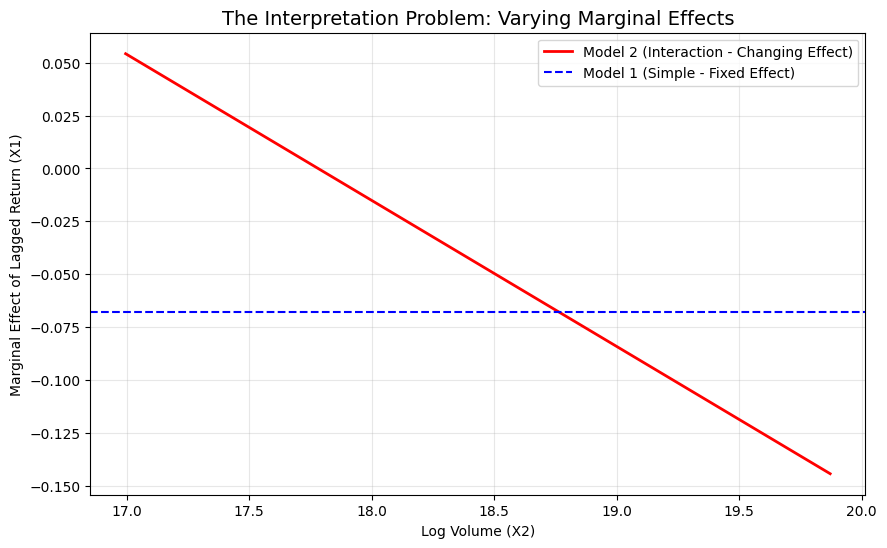

In Model 1, the effect is ALWAYS -0.0678
In Model 2, the effect ranges from -0.1443 to 0.0542 depending on Volume.


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the marginal effect of Ret_Lag across different volume levels
# Marginal Effect = beta_Ret_Lag + beta_Interaction * Log_Vol
b_ret = model2.params['Ret_Lag']
b_interact = model2.params['Vol_x_Ret']

vol_range = np.linspace(df_interp['Log_Vol'].min(), df_interp['Log_Vol'].max(), 100)
marginal_effects = b_ret + b_interact * vol_range

plt.figure(figsize=(10, 6))
plt.plot(vol_range, marginal_effects, color='red', lw=2)
plt.axhline(model1.params['Ret_Lag'], color='blue', linestyle='--', label='Model 1 (Constant Effect)')

plt.title('The Interpretation Problem: Varying Marginal Effects', fontsize=14)
plt.xlabel('Log Volume (X2)')
plt.ylabel('Marginal Effect of Lagged Return (X1)')
plt.legend(['Model 2 (Interaction - Changing Effect)', 'Model 1 (Simple - Fixed Effect)'])
plt.grid(True, alpha=0.3)
plt.show()

print(f"In Model 1, the effect is ALWAYS {model1.params['Ret_Lag']:.4f}")
print(f"In Model 2, the effect ranges from {marginal_effects.min():.4f} to {marginal_effects.max():.4f} depending on Volume.")

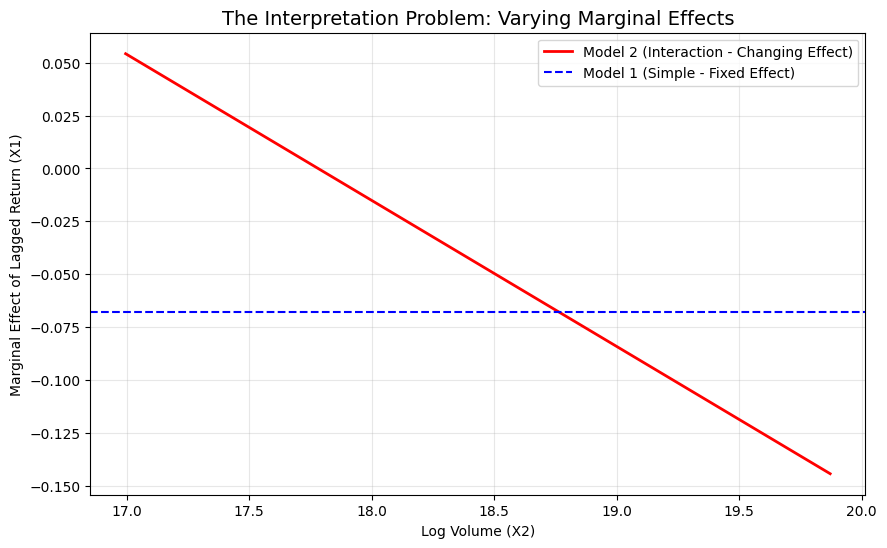

In Model 1, the effect is ALWAYS -0.0678
In Model 2, the effect ranges from -0.1443 to 0.0542 depending on Volume.


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the marginal effect of Ret_Lag across different volume levels
# Marginal Effect = beta_Ret_Lag + beta_Interaction * Log_Vol
b_ret = model2.params['Ret_Lag']
b_interact = model2.params['Vol_x_Ret']

vol_range = np.linspace(df_interp['Log_Vol'].min(), df_interp['Log_Vol'].max(), 100)
marginal_effects = b_ret + b_interact * vol_range

plt.figure(figsize=(10, 6))
plt.plot(vol_range, marginal_effects, color='red', lw=2)
plt.axhline(model1.params['Ret_Lag'], color='blue', linestyle='--', label='Model 1 (Constant Effect)')

plt.title('The Interpretation Problem: Varying Marginal Effects', fontsize=14)
plt.xlabel('Log Volume (X2)')
plt.ylabel('Marginal Effect of Lagged Return (X1)')
plt.legend(['Model 2 (Interaction - Changing Effect)', 'Model 1 (Simple - Fixed Effect)'])
plt.grid(True, alpha=0.3)
plt.show()

print(f"In Model 1, the effect is ALWAYS {model1.params['Ret_Lag']:.4f}")
print(f"In Model 2, the effect ranges from {marginal_effects.min():.4f} to {marginal_effects.max():.4f} depending on Volume.")

### Statistical Tests and Diagnostics for Interpretability

To formally decide if the loss of interpretability (adding complexity) is justified, we use the following:

1. **Likelihood Ratio (LR) Test**:
   - **Purpose**: Compares a 'Restricted' model (simple) to an 'Unrestricted' model (complex/interaction).
   - **Null Hypothesis ($H_0$)**: The simple model is sufficient. If we fail to reject $H_0$, we should stick to the simple, interpretable model.

2. **Bayesian Information Criterion (BIC)**:
   - **Formula**: $BIC = k \ln(n) - 2 \ln(\hat{L})$
   - **Interpretation**: BIC heavily penalizes additional parameters ($k$). In financial econometrics, a lower BIC is preferred. If adding an interaction term increases the BIC, the model is likely over-complex and interpretation is being sacrificed for no real gain.

3. **Partial Dependence Plots (PDP) & SHAP Values**:
   - These are diagnostic tools used for non-linear models to show the marginal effect of a feature on the predicted outcome, effectively 're-interpreting' a black-box model.

### The Danger of Ignoring Interpretability in Finance

When quants prioritize performance (e.g., high accuracy) over interpretability, they introduce significant systemic risks:

1. **The 'Black Box' Flash Crash**: If a model reacts to a specific technical signal that the human trader doesn't understand, the trader cannot intervene when the market environment changes. During the 2010 Flash Crash, many algorithmic models lacked sufficient interpretability for immediate human audit, delaying recovery.
2. **Regulatory and Compliance Risk (SR 11-7)**: In the US and EU, banking regulations (like the Federal Reserve's SR 11-7) require models to be 'transparent and auditable.' If a bank cannot explain why a model denied a loan or triggered a massive sell order, they face severe fines and 'Model Risk' capital charges.
3. **Failure to Detect 'Drift'**: Financial markets are non-stationary. A black-box model might stop working because the underlying relationship (e.g., between interest rates and volatility) has shifted. Without interpretability, quants cannot diagnose that the model is 'broken' until it has already lost significant capital.
4. **Inability to Stress Test**: Effective stress testing requires changing a specific input (like 'What if oil prices double?') and seeing the result. If a model is too complex to interpret, you cannot perform 'What-if' analysis with any confidence.

### The Danger of Ignoring Interpretability in Finance

Lack of interpretation leads to **'Black Box' risk and regulatory failure**:

1.  **Regulatory Non-compliance (SR 11-7)**: Modern banking regulations require models to be explainable. If a bank cannot explain why an automated system sold $1B of assets, they face massive fines and 'Model Risk' capital charges.
2.  **Flash Crash Risk**: During the 2010 Flash Crash, many algorithmic models lacked interpretability. Traders couldn't tell if the model was reacting to a real price drop or a data error, leading to a feedback loop where the 'black box' worsened the panic.
3.  **Inability to Stress Test**: You cannot effectively ask 'What if oil prices double?' if you don't understand the internal logic of your model. Without interpretability, stress testing is just guesswork.

### Improving Interpretability

1. **SHAP (SHapley Additive exPlanations)**: A game-theoretic approach that assigns each feature an importance value for a particular prediction, allowing 'black box' models to be decomposed into individual factor contributions.
2. **LIME (Local Interpretable Model-agnostic Explanations)**: Fits a simple linear model around a specific prediction to explain the local behavior of a complex model.
3. **Post-Estimation Marginal Effects**: For models with interactions, always calculate and plot marginal effects (as shown in our plot) rather than relying on raw coefficients.

In [18]:
from scipy import stats

# 1. Likelihood Ratio Test between Model 1 (Simple) and Model 2 (Complex)
# LR = -2 * (LL_restricted - LL_unrestricted)
lr_stat = -2 * (model1.llf - model2.llf)
p_val = stats.chi2.sf(lr_stat, df=1) # df=1 because we added one interaction term

print(f"--- Likelihood Ratio Test ---")
print(f"LR Statistic: {lr_stat:.4f}")
print(f"p-value:      {p_val:.4e}")

# 2. Compare BIC
print(f"\n--- Information Criteria ---")
print(f"Model 1 (Simple) BIC:  {model1.bic:.2f}")
print(f"Model 2 (Complex) BIC: {model2.bic:.2f}")

if model2.bic < model1.bic:
    print("\nResult: Complexity is justified by better information fit (Lower BIC).")
else:
    print("\nResult: Stick to Model 1. Complexity reduces interpretability without sufficient fit improvement.")

--- Likelihood Ratio Test ---
LR Statistic: 8.3282
p-value:      3.9035e-03

--- Information Criteria ---
Model 1 (Simple) BIC:  -6517.81
Model 2 (Complex) BIC: -6519.23

Result: Complexity is justified by better information fit (Lower BIC).


## Challenge 4: Overfitting

### Definition
Overfitting occurs when a statistical model describes random error or noise instead of the underlying relationship. In financial econometrics, this often happens when a quant uses too many parameters relative to the number of observations, or uses overly complex non-linear functions to 'force' a fit to historical market data.

### Mathematical Representation: The Bias-Variance Tradeoff
The error of a model can be decomposed into three components:

$$E[(y - \hat{f}(x))^2] = \text{Bias}[\hat{f}(x)]^2 + \text{Var}[\hat{f}(x)] + \sigma^2$$

Where:
- **Bias**: Error from erroneous assumptions (e.g., using a linear model for a non-linear process). Overfitted models have **low bias**.
- **Variance**: Error from sensitivity to small fluctuations in the training set. Overfitted models have **high variance**.
- **$\sigma^2$**: Irreducible error (noise).

An overfitted model minimizes training error ($R^2$ approaches 1.0) but fails to generalize to out-of-sample data because it has captured specific noise patterns that do not repeat.

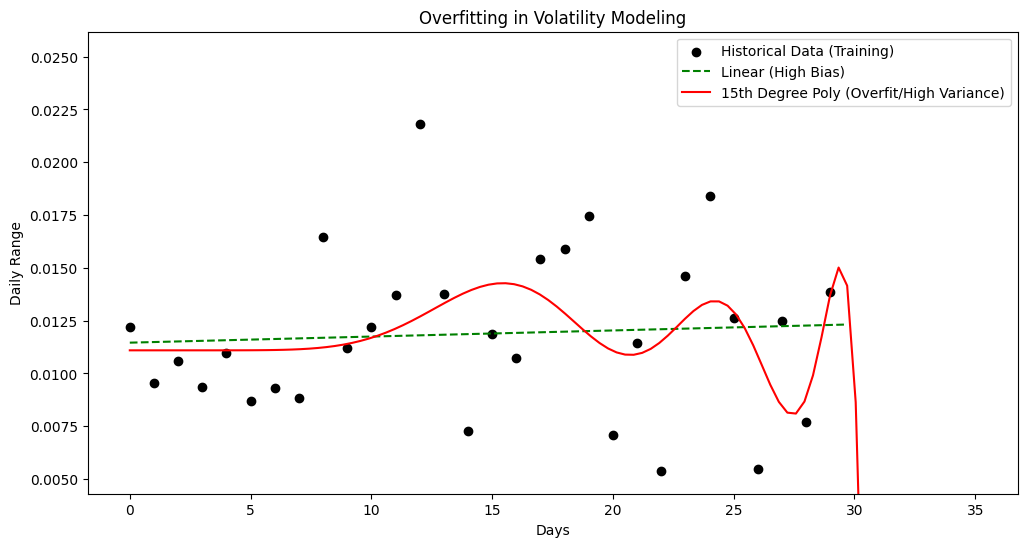

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Prepare small sample to demonstrate overfitting
data = df_interp.tail(30).reset_index()
x_vals = np.arange(len(data)).reshape(-1, 1)
y_vals = data['Range'].values

# 2. Fit a Simple Linear Model (Underfit/Balanced)
model_simple = LinearRegression().fit(x_vals, y_vals)

# 3. Fit a High-Degree Polynomial (Overfit)
poly = PolynomialFeatures(degree=15)
x_poly = poly.fit_transform(x_vals)
model_overfit = LinearRegression().fit(x_poly, y_vals)

# 4. Visualize results
plt.figure(figsize=(12, 6))
plt.scatter(x_vals, y_vals, color='black', label='Historical Data (Training)')

# Plotting
x_range = np.linspace(0, 35, 100).reshape(-1, 1)
plt.plot(x_range[:85], model_simple.predict(x_range[:85]), 'g--', label='Linear (High Bias)')
plt.plot(x_range, model_overfit.predict(poly.transform(x_range)), 'r-', label='15th Degree Poly (Overfit/High Variance)')

plt.title('Overfitting in Volatility Modeling')
plt.xlabel('Days')
plt.ylabel('Daily Range')
plt.ylim(y_vals.min()*0.8, y_vals.max()*1.2)
plt.legend()
plt.show()

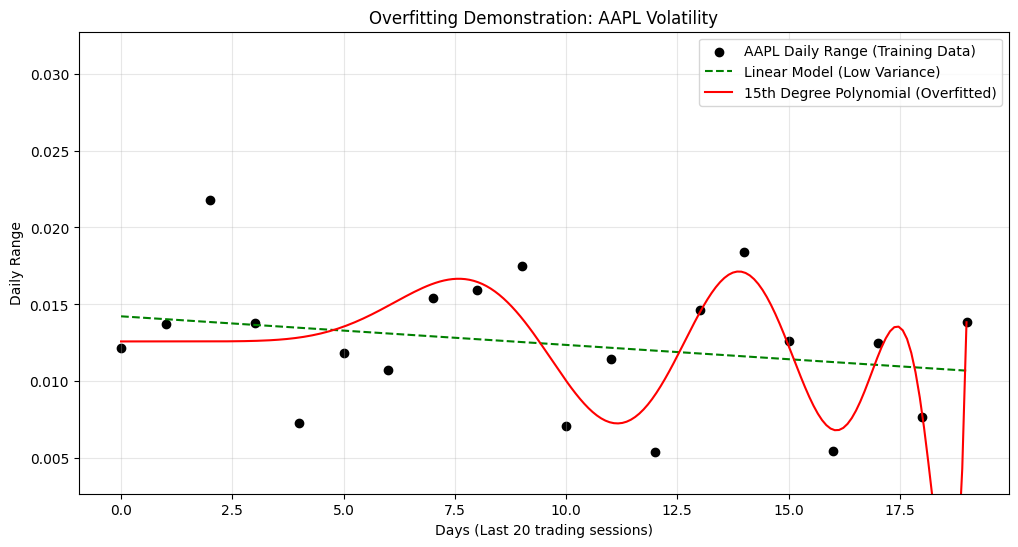

Linear Model R^2: 0.0638
Overfitted Model R^2: 0.4561


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Prepare a small sample of AAPL volatility (Daily Range) to simulate noise
sample_data = df_interp.tail(20).reset_index()
x = np.arange(len(sample_data)).reshape(-1, 1)
y = sample_data['Range'].values

# 2. Fit a Simple Linear Model (Balanced/Underfit)
lin_reg = LinearRegression().fit(x, y)

# 3. Fit a High-Degree Polynomial Model (Overfit)
# Degree 15 on 20 points will almost certainly capture noise
poly_features = PolynomialFeatures(degree=15)
x_poly = poly_features.fit_transform(x)
poly_reg = LinearRegression().fit(x_poly, y)

# 4. Generate points for smooth plotting
x_smooth = np.linspace(0, 19, 200).reshape(-1, 1)
y_lin_pred = lin_reg.predict(x_smooth)
y_poly_pred = poly_reg.predict(poly_features.transform(x_smooth))

# 5. Visualization
plt.figure(figsize=(12, 6))
plt.scatter(x, y, color='black', label='AAPL Daily Range (Training Data)')
plt.plot(x_smooth, y_lin_pred, 'g--', label='Linear Model (Low Variance)')
plt.plot(x_smooth, y_poly_pred, 'r-', label='15th Degree Polynomial (Overfitted)')

plt.title('Overfitting Demonstration: AAPL Volatility')
plt.xlabel('Days (Last 20 trading sessions)')
plt.ylabel('Daily Range')
plt.ylim(y.min()*0.5, y.max()*1.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Linear Model R^2: {lin_reg.score(x, y):.4f}")
print(f"Overfitted Model R^2: {poly_reg.score(x_poly, y):.4f}")

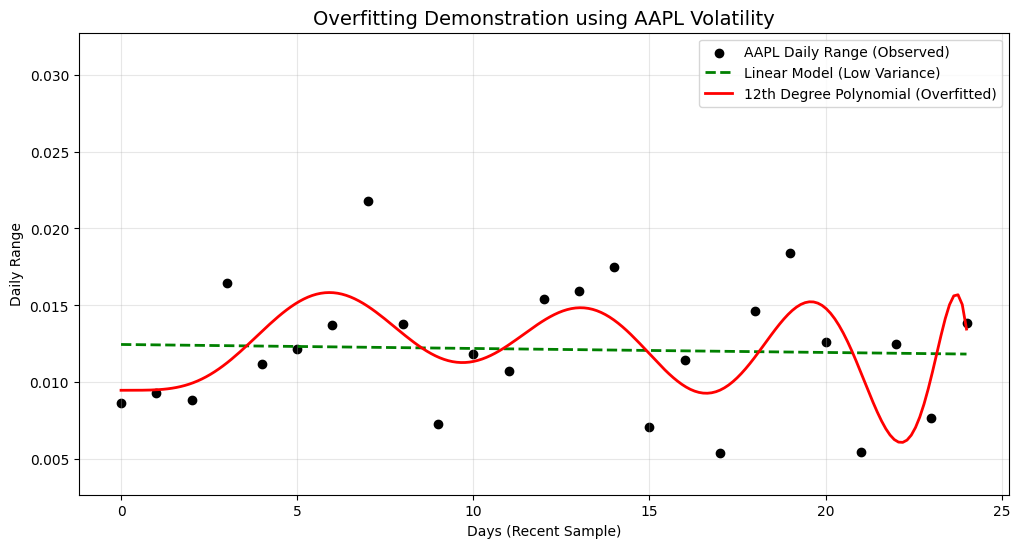

Linear Model R^2: 0.0021
Overfitted Model R^2: 0.3315


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Prepare a small sample of AAPL volatility (Daily Range) from the existing df_interp
data_subset = df_interp.tail(25).reset_index()
x = np.arange(len(data_subset)).reshape(-1, 1)
y = data_subset['Range'].values

# 2. Fit a Simple Linear Model (Balanced/Underfit)
lin_reg = LinearRegression().fit(x, y)

# 3. Fit a High-Degree Polynomial Model (Overfit)
# Using degree 12 on 25 points to demonstrate the high variance
poly_features = PolynomialFeatures(degree=12)
x_poly = poly_features.fit_transform(x)
poly_reg = LinearRegression().fit(x_poly, y)

# 4. Generate points for smooth plotting
x_smooth = np.linspace(0, 24, 200).reshape(-1, 1)
y_lin_pred = lin_reg.predict(x_smooth)
y_poly_pred = poly_reg.predict(poly_features.transform(x_smooth))

# 5. Visualization
plt.figure(figsize=(12, 6))
plt.scatter(x, y, color='black', label='AAPL Daily Range (Observed)')
plt.plot(x_smooth, y_lin_pred, 'g--', label='Linear Model (Low Variance)', lw=2)
plt.plot(x_smooth, y_poly_pred, 'r-', label='12th Degree Polynomial (Overfitted)', lw=2)

plt.title('Overfitting Demonstration using AAPL Volatility', fontsize=14)
plt.xlabel('Days (Recent Sample)')
plt.ylabel('Daily Range')
plt.ylim(y.min()*0.5, y.max()*1.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Linear Model R^2: {lin_reg.score(x, y):.4f}")
print(f"Overfitted Model R^2: {poly_reg.score(x_poly, y):.4f}")

### Statistical Tests for Detection

To identify if a model is overfitting, quants use the following diagnostics:

1. **Train-Test Split / Cross-Validation**:
   - **The Logic**: Split the data into a training set (to build the model) and a testing set (to evaluate it).
   - **Detection**: If the Training $R^2$ is high but the Test $R^2$ is low (or negative), the model has overfitted to the training noise.

2. **Akaike Information Criterion (AIC) & Bayesian Information Criterion (BIC)**:
   - These metrics reward goodness-of-fit but penalize the number of parameters ($k$).
   - **AIC**: $2k - 2\ln(\hat{L})$
   - **BIC**: $k\ln(n) - 2\ln(\hat{L})$
   - **Decision Rule**: A lower AIC/BIC is better. If adding a polynomial degree increases the AIC/BIC, the model is likely overfitting.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import statsmodels.api as sm

# 1. Split AAPL data into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 2. Fit Models on Training Data
lin_train = LinearRegression().fit(X_train, y_train)
poly_train = LinearRegression().fit(poly_features.transform(X_train), y_train)

# 3. Evaluate on Test Data
r2_lin_test = r2_score(y_test, lin_train.predict(X_test))
r2_poly_test = r2_score(y_test, poly_train.predict(poly_features.transform(X_test)))

print(f"--- Generalization Test (Out-of-Sample) ---")
print(f"Linear Model Test R^2:    {r2_lin_test:.4f}")
print(f"Overfitted Model Test R^2: {r2_poly_test:.4f}")

if r2_poly_test < r2_lin_test:
    print("\nResult: Overfitting confirmed. The complex model failed on unseen data.")

--- Generalization Test (Out-of-Sample) ---
Linear Model Test R^2:    -0.9551
Overfitted Model Test R^2: -64.6193

Result: Overfitting confirmed. The complex model failed on unseen data.


### The Danger of Ignoring Overfitting in Finance

Overfitting is perhaps the most common way quants lose money through **'False Alpha'**:

1.  **Backtest Bias**: An overfitted model will show spectacular returns in a backtest because it has 'memorized' the historical noise. However, it will fail immediately in live trading (Out-of-Sample).
2.  **Capital Destruction**: A firm may allocate millions of dollars to a strategy based on a high $R^2$ in training. When the model encounters a single day of new market conditions that don't match its memorized noise, it can trigger catastrophic losses.
3.  **Chasing Ghosts**: Overfitted models find 'patterns' in random fluctuations. A quant might spend months optimizing a strategy around a 'signal' that was actually just a coincidence in the 2022 data, leading to wasted institutional resources.

### Preventing Overfitting

1. **K-Fold Cross-Validation**: Rotate which part of the data is used for 'training' vs 'testing' multiple times to ensure the model performance is robust across different time periods.
2. **Early Stopping**: In iterative models (like Neural Networks or Gradient Boosting), stop training as soon as the validation error starts to rise, even if the training error is still falling.
3. **Pruning and Dropout**: For decision trees, 'pruning' removes branches that provide little predictive power. In neural networks, 'dropout' randomly ignores neurons during training to prevent the model from becoming too reliant on specific noise patterns.